# 05 - Analiza statystyczna zależności

## Cel
Statystyczna weryfikacja zależności między warunkami meteorologicznymi a poziomem wody.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.chdir('..')

from src.data.preprocessing import build_main_df
from src.visualization.plots import *
from src.analysis.statistics import *

final = build_main_df()

Analizę przeprowadzono w następujących etapach:

1. **Analiza korelacji krzyżowej z opóźnieniem** — obliczenie współczynnika Pearsona między dobową sumą opadu a poziomem wody dla opóźnień od 0 do 14 dni.
2. **Macierz korelacji** — analiza współzależności liniowych między wszystkimi zmiennymi.
3. **Porównanie agregatów opadu** — zestawienie korelacji (Pearson) dla wszystkich dni i wyłącznie dla dni z opadem > 0 mm.
4. **Korelacja Spearmana** — ocena monotonicznej zależności odpornej na rozkład asymetryczny.
5. **Regresja liniowa** — oszacowanie współczynnika kierunkowego dla `Opad_72h`.
6. **Analiza grupowa** — porównanie rozkładów poziomu wody w dniach z małym (kwantyl ≤ 25%) i dużym opadem (kwantyl ≥ 75%) za pomocą wykresów KDE i boxplot.
7. **Testy statystyczne** — weryfikacja normalności (test Shapiro-Wilka) oraz istotności różnicy między grupami (test Manna-Whitneya U).

## 1. Korelacja krzyżowa z opóźnieniem (lag 0-14 dni)

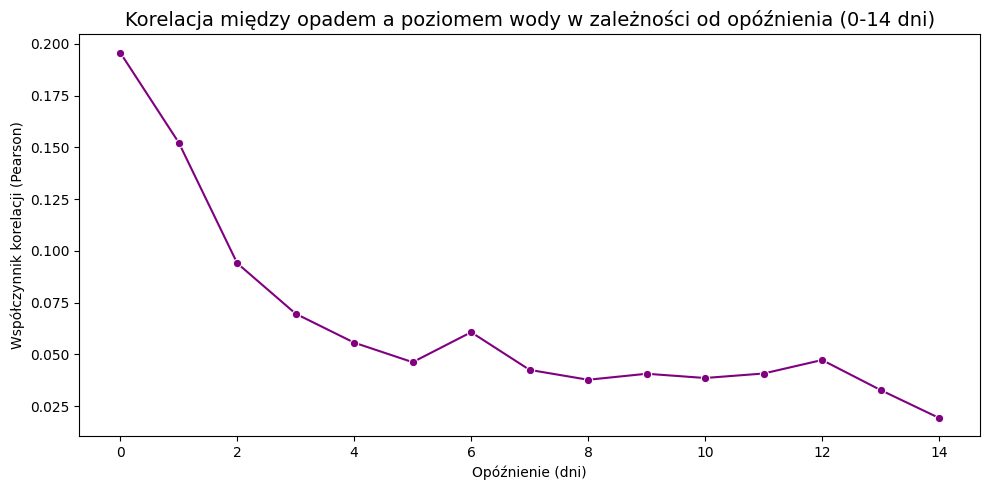

In [2]:
korelacje = korelacja_z_lagami(final)
plot_korelacja_lag_14dni(final)

### Obserwacje

Najwyższą wartość współczynnika korelacji Pearsona odnotowano dla opóźnienia 0 dni (r ≈ 0,196), co wskazuje, że tego samego dnia pomiarowego opad wykazuje najsilniejszy związek z poziomem wody. Korelacja spada gwałtownie w kolejnych dniach, osiągając lokalne minimum w dniu 5 (r ≈ 0,047), po czym nieznacznie wzrasta w dniu 6 (r ≈ 0,062). Później kor. zanika i dla lag > 7 utrzymuje się na poziomie bliskim zeru.

### Interpretacje

Szybka odpowiedź zlewni na opad sugeruje mały obszar dorzecza lub bezpośrednią bliskość stacji pomiarowej do obszarów zasilania. Anomalia w dniu 6 może wskazywać na opóźniony dopływ z wód gruntowych lub retencję wody. Fakt, że wszystkie wartości korelacji pozostają poniżej 0,2 po dniu 0, świadczy o dużym rozproszeniu odpowiedzi i istotnej roli czynników pozaatmosferycznych. Możliwe jest także że zależność między czynnikami nie jest liniowa, a np. progowa.

## 2. Macierz korelacji

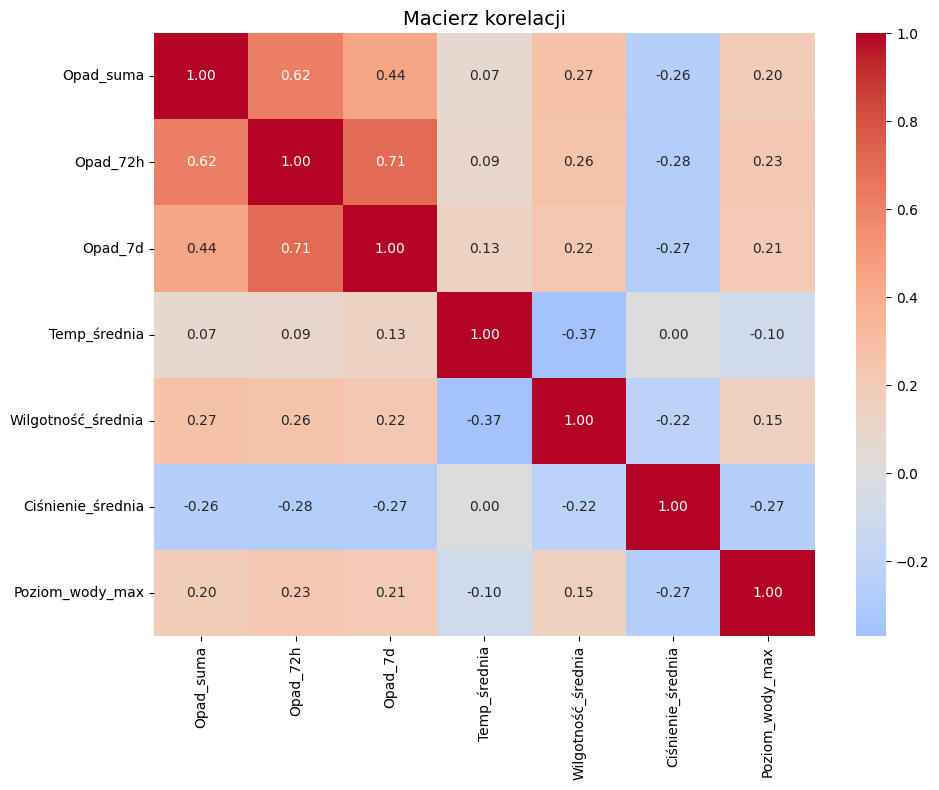

In [3]:
plot_macierz_korelacji(final)

### Obserwacje z macierzy korelacji Pearsona:


- Zmienne opadowe są wzajemnie silnie skorelowane: Opad_72h ↔ Opad_7d (r = 0,71), Opad_suma ↔ Opad_72h (r = 0,62), ponieważ wynikają jedne z drugich.
- Spośród wszystkich zmiennych meteorologicznych, Opad_72h wykazuje najwyższą korelację z poziomem wody (r = 0,23).
- **Ciśnienie_średnia** koreluje ujemnie zarówno z opadem (r ≈ –0,27), jak i z poziomem wody (r = –0,27), co jest zgodne z fizyką atmosfery — niskie ciśnienie sprzyja opadom i podwyższonemu stanowi wód.
- **Temp_średnia** wykazuje niemal zerową korelację z poziomem wody (r = –0,096), co może sugerować brak istotnego efektu roztopowego w badanym okresie lub jego kompensację przez inne czynniki.
- **Wilgotność_średnia** koreluje umiarkowanie z poziomem wody (r = 0,15) oraz z opadami (r ≈ 0,22–0,27), co może odzwierciedlać pośredni związek przez nasycenie gleby.


## 3. Porównanie korelacji — wszystkie dni vs dni z opadem

In [4]:
korelacja_wszystkie_vs_mokre(final)

=== Wszystkie dni ===
Opad_suma             r = 0.196
Opad_72h              r = 0.233
Opad_7d               r = 0.211
Opad_lag_1d           r = 0.152
Opad_lag_2d           r = 0.094
Opad_lag_3d           r = 0.070

=== Tylko dni z opadem > 0 ===
Opad_suma             r = 0.120
Opad_72h              r = 0.177
Opad_7d               r = 0.164


### Obserwacje

| Zmienna | Wszystkie dni (r) | Tylko dni z opadem > 0 (r) |
|---------|-------------------|---------------------------|
| `Opad_suma` | 0,196 | 0,120 |
| `Opad_72h` | 0,233 | 0,177 |
| `Opad_7d` | 0,211 | 0,164 |
| `Opad_lag_1d` | 0,152 | — |
| `Opad_lag_2d` | 0,094 | — |
| `Opad_lag_3d` | 0,070 | — |


Interesującym wynikiem jest **spadek korelacji po ograniczeniu próby 
do dni z opadem**. Oznacza to, że znaczna część korelacji pochodzi 
z kontrastu między dniami suchymi a dniami deszczowymi, a nie 
z wewnętrznego zróżnicowania intensywności opadu. Sugeruje to 
progowy charakter odpowiedzi zlewni.

Najsilniejszym predyktorem liniowym pozostaje Opad_72h (r = 0,233),
skumulowany opad z ostatnich 3 dni lepiej opisuje stan wód niż 
opad dobowy.

## 4. Korelacja Spearmana

In [5]:
korelacja_spearmana(final)

0.2916185123966498


np.float64(0.2916185123966498)

### Interpretacja

Współczynnik korelacji rang Spearmana między `Opad_suma` a `Poziom_wody_max` wynosi **ρ = 0,287**, co jest wyższe od odpowiadającego mu współczynnika Pearsona (r = 0,196). Różnica ta wskazuje na **obecność monotonicznej, lecz nieliniowej zależności** między zmiennymi. Korelacja Spearmana jest w tym przypadku bardziej adekwatną miarą niż Pearson.


## 5. Regresja liniowa

[0.00632912]


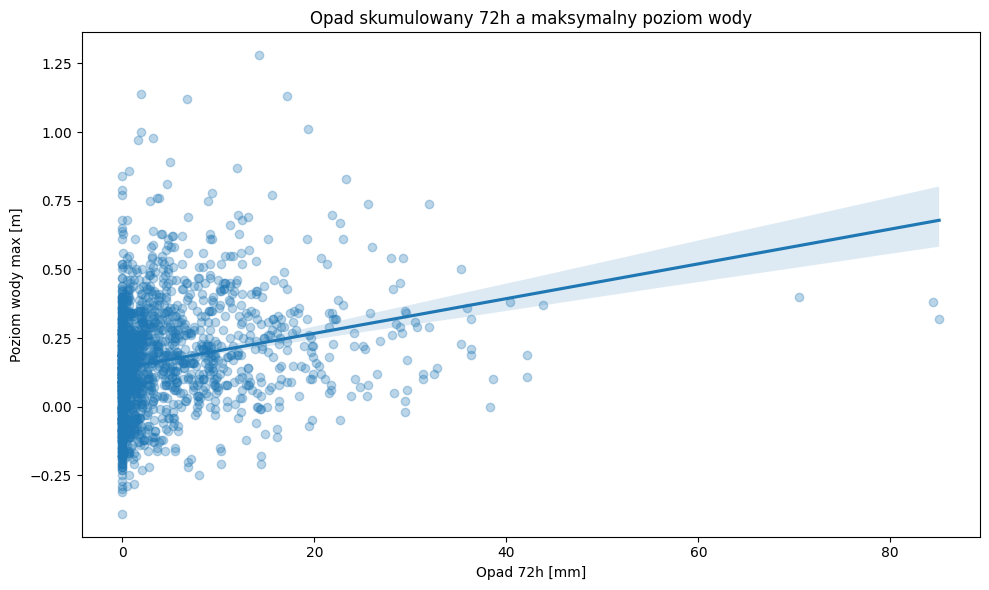

In [6]:
model = regresja_liniowa(final)
plot_regresja_opad_woda(final)

### Obserwacje

Współczynnik kierunkowy regresji liniowej dla pary 
(`Opad_72h`, `Poziom_wody_max`) wynosi **β = 0,00633 m/mm**, 
co oznacza, że każdy dodatkowy milimetr skumulowanego opadu 
z okresu 72 godzin wiąże się ze średnim wzrostem maksymalnego 
poziomu wody o około 0,6 cm.

Wykres rozrzutu pokazuje że:
- Gęste skupisko obserwacji przy `Opad_72h` ≈ 0 mm z szerokim 
  zakresem poziomu wody (od -0,3 m do +1,3 m) — poziom wody 
  jest kształtowany przez wiele czynników niezależnie od opadu
- Wyraźny trend wzrostowy widoczny dopiero przy wyższych 
  wartościach opadu (> 20 mm/72h)
- Duże przedziały ufności dla wysokich wartości opadu wynikają 
  z małej liczby takich obserwacji

Model liniowy z samym opadem 72h bardzo słabo przewiduje 
konkretny poziom wody.

## 6. Analiza grupowa

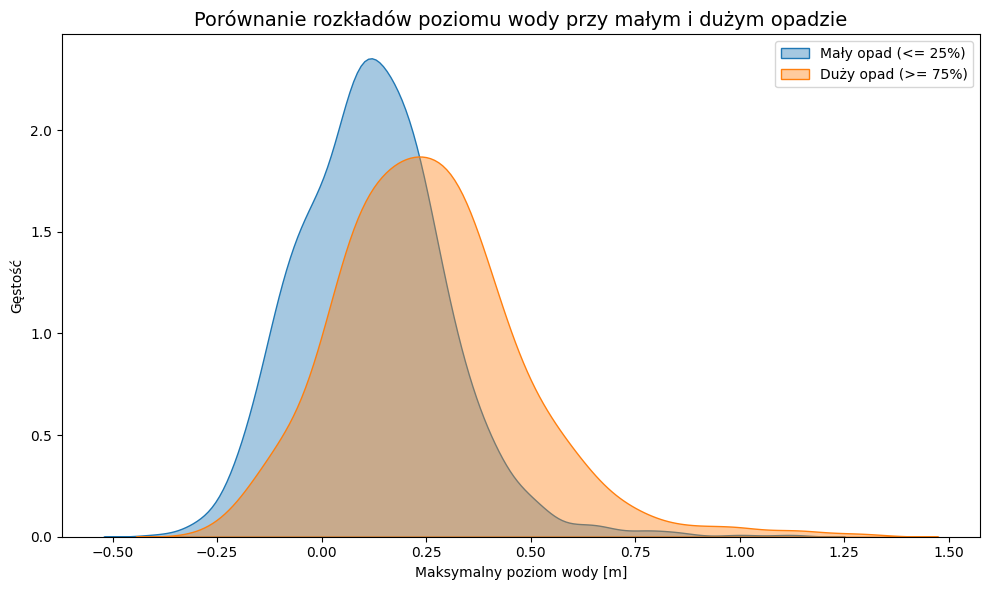

In [7]:
plot_kde_opad_grupy(final)

### Obserwacje i Interpretacja

Rozkład poziomu wody przy dużym opadzie (kwantyl ≥ 75%) jest wyraźnie **przesunięty w prawo** w stosunku do rozkładu przy małym opadzie (kwantyl ≤ 25%). Szczyt rozkładu dla dużego opadu (~0,25 m) jest wyższy niż dla małego opadu (~0,07 m). Ponadto rozkład dla dużego opadu wykazuje wyraźniejszą asymetrię prawostronną (ogon), sygnalizując obecność ekstremalnych zdarzeń wezbraniowych.


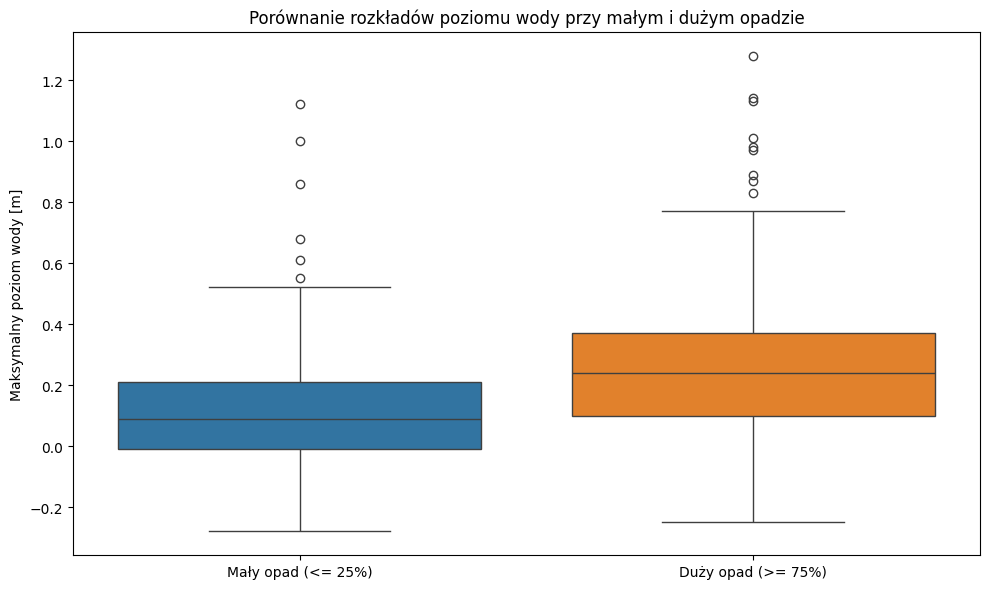

In [8]:
plot_boxplot_opad_grupy(final)

### Dalsza Interpretacja
Boxplot potwierdza obserwacje z KDE:

- Mediana poziomu wody przy **dużym opadzie** (~0,24 m) jest wyraźnie wyższa niż przy małym (~0,10 m).
- Rozstęp IQR jest większy w grupie dużego opadu, co wskazuje na wyższą zmienność poziomów wody.
- Obie grupy wykazują wartości odstające po stronie wysokich poziomów wody, jednak w grupie dużego opadu są one liczne i sięgają do ~1,3 m.
- Obecność ujemnych wartości w grupie małego opadu może sugerować deficyt wodny (susza hydrologiczna) lub specyfikę skali pomiarowej.


## 7. Testy statystyczne

test_normalnosci(final)


| Grupa             | p-value      | Wniosek                |
| ----------------- | ------------ | ---------------------- |
| Mały opad (≤ Q25) | 9,51 × 10⁻¹³ | Odrzucenie normalności |
| Duży opad (≥ Q75) | 3,95 × 10⁻⁹  | Odrzucenie normalności |

Oba rozkłady są istotnie różne od rozkładu normalnego, co wyklucza zastosowanie testu t-Studenta i uzasadnia wybór testu nieparametrycznego.


In [9]:
test_manna_whitneya(final)

4.639356621361879e-31


np.float64(4.639356621361879e-31)


|         | Wartość                               |
| ------- | ------------------------------------- |
| p-value | 4,64 × 10⁻³¹                          |
| Wniosek | Wysoce istotna różnica między grupami |

Test sprawdził, czy różnica w poziomach wody między dniami z małym i dużym opadem mogła pojawić się przez przypadek. Wynik p = 4,64 × 10⁻³¹ oznacza, że prawdopodobieństwo przypadkowego uzyskania tak dużej różnicy jest praktycznie zerowe — poziom wody jest więc realnie wyższy w dniach z dużym opadem.


## Podsumowanie

### Zestawieniw wyników korelacji

| Miara          | Zmienna                    | Wartość      |
| -------------- | -------------------------- | ------------ |
| Pearson r      | Opad_suma (wszystkie dni)  | 0,196        |
| Pearson r      | Opad_72h (wszystkie dni)   | 0,233        |
| Pearson r      | Opad_7d (wszystkie dni)    | 0,211        |
| Pearson r      | Opad_lag_1d                | 0,152        |
| Pearson r      | Opad_lag_2d                | 0,094        |
| Pearson r      | Opad_lag_3d                | 0,070        |
| Pearson r      | Opad_suma (dni z opadem)   | 0,120        |
| Pearson r      | Opad_72h (dni z opadem)    | 0,177        |
| Pearson r      | Opad_7d (dni z opadem)     | 0,164        |
| Spearman ρ     | Opad_suma                  | 0,287        |
| Regresja β     | Opad_72h → Poziom_wody_max | 0,00633 m/mm |
| Mann-Whitney p | Mały vs. duży opad         | 4,64 × 10⁻³¹ |


Przeprowadzona analiza ujawnia **słabą, lecz spójną i statystycznie istotną zależność** między opadem atmosferycznym a poziomem wody. Konsekwentnie niskie wartości współczynnika Pearsona (r < 0,25) przy jednoczesnej wysokiej istotności testu Manna-Whitneya są pozornie sprzeczne, jednak wyjaśniają się w kontekście specyfiki danych:

1. **Asymetryczny rozkład opadu** — dominacja dni suchych (Opad_suma = 0) osłabia korelacje liniowe. Spearman daje wyższą wartość (ρ = 0,287), co sugeruje relację monotoniczną, nie liniową.

2. **Progowy charakter odpowiedzi** — korelacja spada po ograniczeniu próby do dni z opadem, co wskazuje że dopiero po przekroczeniu progu nasycenia zlewni opad efektywnie przekłada się na wzrost poziomu wody.

3. **Wieloczynnikowość procesu** — poziom wody jest wypadkową wielu zmiennych (temperatura, ewapotranspiracja, stan wód gruntowych, zarządzanie zbiornikami) spoza zakresu niniejszej analizy.

4. **Skala agregacji** — `Opad_72h` konsekwentnie przewyższa `Opad_suma` jako predyktor, co jest zgodne z hydrologiczną teorią odpowiedzi zlewni.
